In [2]:
print("hello")

hello


In [3]:
from dotenv import load_dotenv
import os

# This looks for the .env file in the exact same folder as this script
load_dotenv(os.path.join(os.getcwd(), '.env')) 


True

In [4]:
import os
import glob
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document

from langchain_google_genai import GoogleGenerativeAIEmbeddings 


DOCS_DIR = "sample_docs"
# Create the directory if it doesn't exist so glob doesn't fail
if not os.path.exists(DOCS_DIR):
    os.makedirs(DOCS_DIR)

def load_and_split(docs_dir):
    chunks = []
    # Use glob to find all .txt files
    files = glob.glob(os.path.join(docs_dir, "*.txt"))
    
    for path in files:
        with open(path, "r", encoding="utf-8") as f: # Fixed: encoding
            text = f.read()
            
        source = os.path.basename(path)
        # This splits every time you hit a new line
        paragraphs = [p.strip() for p in text.split("\n") if p.strip()]

        
        current = ""
        for para in paragraphs:
            if len(current) + len(para) + 2 <= 200:
                current = (current + "\n\n" + para).strip()
            else:
                if current:
                    chunks.append(Document(page_content=current, metadata={"source": source}))
                current = para
        if current:
            chunks.append(Document(page_content=current, metadata={"source": source})) 
    return chunks

chunks = load_and_split(DOCS_DIR)
print(f"Loaded {len(chunks)} chunks from {DOCS_DIR}")


Loaded 14 chunks from sample_docs


In [ ]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.vectorstores import FAISS

# 1. Use the simple name. The library will handle the rest.
embeddings = GoogleGenerativeAIEmbeddings(
    model="text-embedding-004",
    task_type="retrieval_document"
)

# 2. Run the indexing
if chunks:
    print("Creating index... (Connecting to Google API)")
    try:
        vector_store = FAISS.from_documents(chunks, embeddings)
        vector_store.save_local("faiss_index")
        print("DONE! 'faiss_index' folder created successfully.")
    except Exception as e:
        print(f"Error occurred: {e}")



Creating index... (Connecting to Google API)
Error occurred: Error embedding content (NOT_FOUND): 404 NOT_FOUND. {'error': {'code': 404, 'message': 'models/text-embedding-004 is not found for API version v1beta, or is not supported for embedContent. Call ListModels to see the list of available models and their supported methods.', 'status': 'NOT_FOUND'}}


In [8]:
import os
import google.generativeai as genai
from dotenv import load_dotenv

# 1. Load your key
load_dotenv()
api_key = os.getenv("GOOGLE_API_KEY")
genai.configure(api_key=api_key)

print("Searching for available embedding models...")
try:
    # 2. List all models that support embeddings
    count = 0
    for m in genai.list_models():
        if 'embedContent' in m.supported_generation_methods:
            print(f"✅ FOUND: {m.name}")
            count += 1
    
    if count == 0:
        print("❌ No embedding models found. Check if your API Key has 'Generative Language API' enabled in Google Cloud Console.")
        
except Exception as e:
    print(f"Error listing models: {e}")


c:\Users\Admin\Desktop\RAG_Project\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Admin\AppData\Local\Temp\ipykernel_9608\159307044.py:2: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


Searching for available embedding models...
✅ FOUND: models/gemini-embedding-001
✅ FOUND: models/gemini-embedding-2-preview


In [9]:
import os
from dotenv import load_dotenv
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.vectorstores import FAISS

load_dotenv()

# 1. Use the EXACT model name that was FOUND
embeddings = GoogleGenerativeAIEmbeddings(
    model="models/gemini-embedding-001",
    task_type="retrieval_document"
)

# 2. Create the index
if chunks:
    print("Creating index with gemini-embedding-001...")
    vector_store = FAISS.from_documents(chunks, embeddings)
    vector_store.save_local("faiss_index")
    print("✅ SUCCESS! 'faiss_index' folder created.")
else:
    print("❌ No chunks found to index.")


Creating index with gemini-embedding-001...
✅ SUCCESS! 'faiss_index' folder created.


In [1]:
import os
import time
from typing import Annotated, List, TypedDict
from dotenv import load_dotenv

# LangChain & LangGraph Imports
from langchain_groq import ChatGroq
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver

# 1. LOAD API KEYS
load_dotenv()

# 2. DEFINE THE SEARCH TOOL
@tool
def search_transformer_docs(query: str) -> str:
    """Use this tool to search for information about transformers, voltage, and Michael Faraday."""
    # Small sleep to respect Google's free-tier rate limits
    time.sleep(1) 
    
    # Load your existing FAISS index
    embeddings = GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001")
    vector_store = FAISS.load_local("faiss_index", embeddings, allow_dangerous_deserialization=True)
    
    # Perform search
    docs = vector_store.similarity_search(query, k=2)
    return "\n\n".join([doc.page_content for doc in docs])

tools = [search_transformer_docs]
tool_node = ToolNode(tools)

# 3. CONFIGURE LLM (GROQ)
# Binding tools tells the LLM it has access to the search function
llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)
llm_with_tools = llm.bind_tools(tools)

# 4. DEFINE STATE SCHEMA
class AgentState(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]

# 5. SYSTEM PROMPT (Crucial for fixing Error 400)
SYSTEM_PROMPT = SystemMessage(content=(
    "You are a helpful RAG assistant. "
    "When asked about electrical transformers or Faraday, you MUST use the search_transformer_docs tool. "
    "After using the tool, summarize the findings for the user. "
    "If the information is not found, state that you do not know."
))

# 6. DEFINE GRAPH NODES
def call_model(state: AgentState):
    messages = state["messages"]
    # Ensure system instructions are always present
    if not isinstance(messages[0], SystemMessage):
        messages = [SYSTEM_PROMPT] + messages
    
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

def route_tools(state: AgentState):
    last_msg = state["messages"][-1]
    if last_msg.tool_calls:
        return "tools"
    return END

# 7. BUILD THE WORKFLOW
builder = StateGraph(AgentState)

builder.add_node("agent", call_model)
builder.add_node("tools", tool_node)

builder.add_edge(START, "agent")
builder.add_conditional_edges("agent", route_tools)
builder.add_edge("tools", "agent")

# 8. COMPILE WITH MEMORY (For conversation history)
memory = MemorySaver()
agent_app = builder.compile(checkpointer=memory)

# 9. EXECUTE THE AGENT
config = {"configurable": {"thread_id": "transformer_session_01"}}
inputs = {"messages": [HumanMessage(content="What did Michael Faraday do in 1831?")]}

try:
    # Use recursion_limit to stop the agent if it gets into a loop
    for chunk in agent_app.stream(inputs, config, recursion_limit=10):
        for node, values in chunk.items():
            if node == "agent":
                content = values["messages"][-1].content
                if content:
                    print(f"\n[AI]: {content}")
            elif node == "tools":
                print("\n[System]: Agent is searching the FAISS index...")
except Exception as e:
    print(f"\nAn error occurred: {e}")



[System]: Agent is searching the FAISS index...

[AI]: In 1831, Michael Faraday discovered the principle of electromagnetic induction, which led to the development of the first transformer. This discovery was a crucial step in the understanding of electricity and paved the way for the creation of modern electrical systems.


In [2]:
# The agent should remember we are talking about Faraday and 1831
follow_up = {"messages": [HumanMessage(content="Who carried his idea forward?")]}

for chunk in agent_app.stream(follow_up, config):
    for node, values in chunk.items():
        if node == "agent":
            print(f"\n[AI]: {values['messages'][-1].content}")



[AI]: 

[AI]: The idea of Michael Faraday was carried forward by many other prominent science scholars, however, their names are not specified in the search results. I do not know who specifically carried his idea forward.


In [3]:
from langgraph.checkpoint.memory import MemorySaver

# 1. Initialize Memory
memory = MemorySaver()

# 2. Re-compile the graph with memory
# (Using your 'builder' from the previous step)
app = builder.compile(checkpointer=memory)


In [5]:
# Turn 1
config = {"configurable": {"thread_id": "user_1"}}
input_message = {"messages": [("user", "Who discovered the idea of a transformer?")]}

for event in app.stream(input_message, config):
    for value in event.values():
        print(value["messages"][-1].content)

# Turn 2: The agent will remember "it" refers to the transformer
input_message_2 = {"messages": [("user", "In what year did this happen?")]}

for event in app.stream(input_message_2, config):
    for value in event.values():
        print(value["messages"][-1].content)



power. The idea of a transformer was first discussed by Michael Faraday in the year 1831 and was carried forward by many other prominent

science scholars. However, the general purpose of using transformers was to maintain a balance between the electricity that was
The idea of a transformer was first discussed by Michael Faraday in 1831 and was later developed by other prominent scholars.
The idea of a transformer was first discussed by Michael Faraday in 1831.


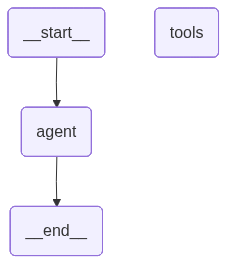

In [6]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    # If dependencies are missing, it will just skip
    print("Graph compiled successfully!")


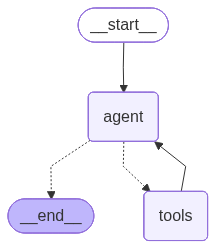

In [8]:
from langgraph.graph import StateGraph, START, END

# 1. Start fresh (this clears the previous 'already exists' errors)
builder = StateGraph(AgentState)

# 2. Add your Nodes
builder.add_node("agent", call_model)
builder.add_node("tools", tool_node)

# 3. Define the Flow (The "Roads")
builder.add_edge(START, "agent")

# Add the conditional path
builder.add_conditional_edges(
    "agent",
    route_tools,
    {
        "tools": "tools", 
        END: END
    }
)

# Crucial: Connect tools back to agent so it can use the search results
builder.add_edge("tools", "agent")

# 4. Compile
memory = MemorySaver()
agent_app = builder.compile(checkpointer=memory)

# 5. Visualize (The graph should now have a loop!)
try:
    from IPython.display import Image, display
    display(Image(agent_app.get_graph().draw_mermaid_png()))
except Exception:
    print("Graph compiled successfully with a loop!")
